[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/07_visualization_and_stats.ipynb)

# 📓 Notebook 7 (fast track) — Visualization & Statistics

> **Module:** Data Science Libraries · **Estimated time:** 70–90 min · **Difficulty:** Beginner → Intermediate

Two skills that turn a DataFrame into a *decision*: drawing the chart that makes the pattern obvious, and running the statistic that tells you whether the pattern is real. This notebook keeps the essentials of both — **charts in a few lines** with pandas `.plot()`, **seaborn**, and a pinch of matplotlib, then the **statistics** toolkit (distributions, confidence intervals, hypothesis tests) — in one lean pass. It builds directly on pandas (Notebook 6).

> 🏎️ **You're on the fast track.** This is a trimmed, **combined** notebook that condenses two canonical chapters into one: [`02_data_science/09_matplotlib_basics.ipynb`](../02_data_science/09_matplotlib_basics.ipynb) (visualization with pandas, seaborn & matplotlib) and [`02_data_science/10_statistics_basics.ipynb`](../02_data_science/10_statistics_basics.ipynb) (Statistics). From each, the Stretch A/B exercises and the 🎁 Bonus mini-project have been removed to keep the path lean — the core teaching, every Practice exercise, and Stretch C/D are kept. Open the canonical versions once you want the deeper material.

---

# 📊 Part 1 — Visualization with pandas, seaborn & matplotlib  *(canonical NB 9)*

## 1. Setup — three imports and one style line

We use three libraries together, and they are friends, not rivals:

- **pandas** — you already have your data in a DataFrame; `.plot()` draws it directly.
- **seaborn** — statistical charts with beautiful defaults; imported as `sns`.
- **matplotlib** — the engine underneath both; we call it directly only for small touch-ups.

`sns.set_theme()` restyles *every* chart in the notebook — including pandas and raw matplotlib plots — because everything renders through matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")   # one line → every plot below looks polished

print(f"pandas {pd.__version__} · seaborn {sns.__version__}")

pandas 3.0.3 · seaborn 0.13.2


> 💡 **One styling line instead of a dozen.** The old-school way is a `plt.rcParams.update({...})` block with ten hand-picked settings. `sns.set_theme()` does that for you. Try `style="darkgrid"`, `"white"`, or `"ticks"` if you prefer a different look.
>
> 💡 **The trailing semicolon.** When a plotting call is the last line of a cell, Jupyter echoes its return value (something like `<Axes: >`) above the chart. End the line with `;` to suppress that noise.

## 2. The dataset — 500 LLM support calls

One realistic DataFrame carries the whole notebook: 500 LLM calls from an AI support operation, with the model used, the support channel, token count, cost, latency, and a customer-satisfaction score.

In [2]:
rng = np.random.default_rng(42)
n = 500

calls = pd.DataFrame({
    "model":     rng.choice(["gpt-4o-mini", "claude-haiku"], n),
    "channel":   rng.choice(["Email", "Chat", "Phone", "Web Form"], n, p=[0.3, 0.4, 0.2, 0.1]),
    "tokens_in": rng.integers(120, 2_000, n),
})
calls["cost_usd"]     = calls["tokens_in"] / 1000 * np.where(calls["model"] == "gpt-4o-mini", 0.0006, 0.0008)
calls["latency_ms"]   = np.where(calls["model"] == "gpt-4o-mini",
                                 rng.normal(1800, 400, n), rng.normal(2300, 500, n)).clip(min=200)
calls["satisfaction"] = (4.6 - 600 * calls["cost_usd"] + rng.normal(0, 0.4, n)).clip(1, 5)

calls.head()

,model,channel,tokens_in,cost_usd,latency_ms,satisfaction
0,gpt-4o-mini,Chat,1115,0.000669,1503.123162,4.163154
1,claude-haiku,Phone,609,0.000487,1586.431799,4.135497
2,claude-haiku,Chat,550,0.000440,1416.188944,4.654618
3,gpt-4o-mini,Email,726,0.000436,1686.881700,4.244306
4,gpt-4o-mini,Email,1243,0.000746,1757.527228,4.029841


…and one small monthly table for trends: the share of conversations resolved without a human, per channel.

In [3]:
monthly = pd.DataFrame({
    "Chat":     [0.55, 0.58, 0.60, 0.63, 0.65, 0.68, 0.70, 0.72, 0.74, 0.76, 0.78, 0.81],
    "Email":    [0.42, 0.45, 0.47, 0.50, 0.52, 0.55, 0.57, 0.60, 0.62, 0.65, 0.67, 0.70],
    "Phone":    [0.15, 0.16, 0.17, 0.18, 0.20, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.28],
    "Web Form": [0.62, 0.65, 0.68, 0.70, 0.72, 0.74, 0.76, 0.78, 0.80, 0.82, 0.83, 0.85],
}, index=pd.Index(range(1, 13), name="month"))

monthly.head(3)

,Chat,Email,Phone,Web Form
month,,,,
1,0.55,0.42,0.15,0.62
2,0.58,0.45,0.16,0.65
3,0.60,0.47,0.17,0.68


## 3. Line plots — a trend in one line

A DataFrame knows how to draw itself. `.plot()` uses the index as the x-axis, draws every column as its own line, and builds the legend from the column names:

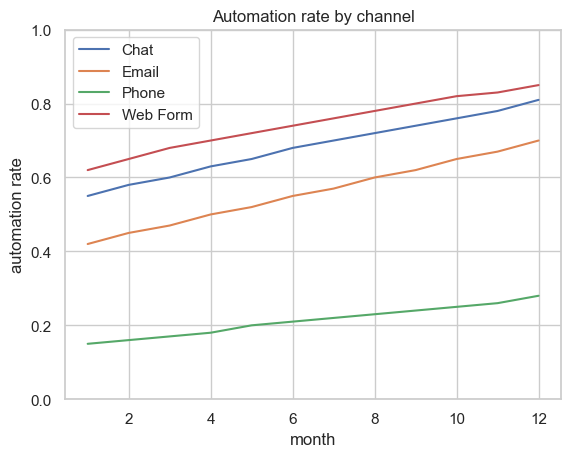

In [4]:
monthly.plot(title="Automation rate by channel", ylabel="automation rate", ylim=(0, 1));

One line — and it replaced about fifteen lines of classic matplotlib (four `ax.plot(...)` calls, manual colors, a legend, labels, limits). Everything came from the DataFrame itself: x-axis from the index, one line per column, legend from the column names.

A single column works the same way:

```python
monthly["Chat"].plot(title="Automation rate — Chat");
```

And when you have plain **arrays or lists** instead of a DataFrame, raw matplotlib is still the quickest two-liner:

```python
plt.plot(range(1, 13), rates, marker="o")
plt.title("Automation rate — Chat");
```

## 4. Bar charts — comparing categories

Comparing categories almost always starts with a `groupby` — and the result plots itself:

In [ ]:
calls.groupby("channel")["cost_usd"].sum().plot(kind="bar", title="Total spend by channel", ylabel="USD", rot=0);

Two habits that make bar charts instantly more readable:

1. **Sort first** — `.sort_values()` turns an arbitrary order into a ranking the eye can follow.
2. **Go horizontal for long labels** — `kind="barh"` keeps category names readable instead of rotating them.

In [ ]:
calls["channel"].value_counts().sort_values().plot(kind="barh", title="Calls per channel");

When the bar height is a **mean**, use seaborn — `sns.barplot` computes the group means *and* adds 95% confidence intervals automatically, so the viewer can see which differences are solid and which are noise:

In [ ]:
sns.barplot(data=calls, x="channel", y="satisfaction")
plt.title("Mean satisfaction per channel (error bars = 95% CI)");

## 5. Histograms — distributions

A histogram tells you the *shape* of one variable: bell-shaped, skewed, bimodal? Crucial before you start modelling — and one line away:

In [ ]:
calls["latency_ms"].plot(kind="hist", bins=30, title="Latency distribution", xlabel="latency (ms)");

The next question is almost always *“does the distribution differ by group?”* In classic matplotlib that means two `hist` calls, manual `alpha`, manual colors, a manual legend. In seaborn it is **one argument**: `hue=`.

In [ ]:
sns.histplot(data=calls, x="latency_ms", hue="model", bins=30)
plt.title("Latency by model");

> 💡 **`hue=` is seaborn's superpower.** Almost every seaborn function accepts it, and it always means the same thing: *split this chart by category — colors, legend and all.* Remember this one argument and you can retire a whole class of for-loops.
>
> 💡 Add `kde=True` to overlay a smooth density curve, or use `sns.kdeplot(...)` for the curves alone.

## 6. Scatter plots — relationships

For *“is X related to Y?”* use a scatter. pandas has it built in:

In [ ]:
calls.plot.scatter(x="cost_usd", y="satisfaction", alpha=0.5, title="Cost vs satisfaction");

Color the points by category? Same trick as before — `hue=`:

In [ ]:
sns.scatterplot(data=calls, x="cost_usd", y="satisfaction", hue="model", alpha=0.6)
plt.title("Cost vs satisfaction, by model");

And the trend line — which used to mean `np.polyfit` plus a manual line plot — is one call with `sns.regplot`:

In [ ]:
sns.regplot(data=calls, x="cost_usd", y="satisfaction",
            scatter_kws={"alpha": 0.3}, line_kws={"color": "crimson"})
plt.title("Cost vs satisfaction — with trend line");

**Reading the chart.** The downward trend line says higher-cost calls tend to come with slightly lower satisfaction — plausibly because expensive calls are the hard ones the bot couldn't fully handle. The shaded band around the line is a confidence interval, which `regplot` adds for free.

## 7. Box plots — several distributions side by side

When you want to compare *several* distributions at once, a box plot is denser than a row of histograms — and `sns.boxplot` needs only the column names:

In [ ]:
sns.boxplot(data=calls, x="model", y="latency_ms")
plt.title("Latency per model");

**Reading a box plot.** The box covers the interquartile range (Q1 to Q3), the line inside is the **median**, whiskers extend to data within 1.5×IQR, and points beyond are outliers. A wide box = high variance; a tight box = consistent performance.

> 💡 Two free upgrades, both still one line: add `hue="channel"` for grouped boxes, or swap in `sns.violinplot(...)` to see the full shape of each distribution instead of just its quartiles.

## 8. Heatmaps — a matrix in one line

Heatmaps are perfect for correlation matrices, confusion matrices, or any “every-row-by-every-column” comparison. `annot=True` writes the numbers into the cells — something that takes a nested for-loop in raw matplotlib:

In [ ]:
num_cols = ["tokens_in", "cost_usd", "latency_ms", "satisfaction"]

sns.heatmap(calls[num_cols].corr(), annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation matrix");

**Reading the heatmap.** `tokens_in` and `cost_usd` are almost perfectly correlated (cost is driven by tokens), cost and satisfaction are negatively related, and latency is driven by the *model*, not by the numeric columns — which is why its correlations are weak.

**The same one-liner draws confusion matrices.** In NB 8 you will evaluate a real classifier — `sns.heatmap(cm, annot=True)` is all it takes to visualize where the model is confused.

## 9. Many charts at once

### The ultimate one-liner: `sns.pairplot`

One call draws a scatter plot for every pair of numeric columns plus a distribution on the diagonal — colored by category. It is the fastest “show me everything” command in Python:

In [ ]:
sns.pairplot(calls[["tokens_in", "cost_usd", "latency_ms", "satisfaction", "model"]],
             hue="model", height=2);

### A 2×2 dashboard — one layout line, four one-liners

Sometimes you want a *specific* set of panels. Create the grid with a single `plt.subplots(2, 2)` call, then fill each panel by passing `ax=` to pandas or seaborn — every plotting tool in this notebook accepts it. This 2×2 layout is the canonical “executive dashboard” shape used in the full course's capstone (NB 24) — and you just learned the short way to build it.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("AI-ops dashboard — 500-call sample", fontweight="bold")

calls["tokens_in"].plot(kind="hist", bins=25, ax=axes[0, 0], title="Tokens per call")
sns.scatterplot(data=calls, x="latency_ms", y="cost_usd", hue="model", s=15, ax=axes[0, 1])
calls.groupby("model")["cost_usd"].mean().plot(kind="bar", ax=axes[1, 0], title="Mean cost per call", rot=0)
sns.boxplot(data=calls, x="model", y="latency_ms", ax=axes[1, 1])

axes[0, 1].set_title("Cost vs latency")
axes[1, 1].set_title("Latency per model")
fig.tight_layout();

## 10. Polish & saving — just enough matplotlib

Most polish is an **argument**, not extra code: `title=`, `xlabel=`, `ylabel=`, `figsize=`, `ylim=`, `rot=`, `legend=`. When you need more, remember that every pandas and seaborn call **returns a matplotlib `Axes`** — so the full matplotlib toolbox is one variable away:

In [ ]:
ax = monthly.plot(figsize=(8, 4), title="Automation rate by channel", ylabel="automation rate")
ax.set_ylim(0, 1)                  # any matplotlib method works on the returned Axes
ax.legend(loc="lower right")

# plt.savefig("automation_rate.png", dpi=200, bbox_inches="tight")   # ← uncomment to save

> 💡 **Saving figures.** Call `plt.savefig("name.png", dpi=200, bbox_inches="tight")` in the same cell as the plot. Use `.png` for reports and the web, `.pdf`/`.svg` for slides and papers (infinitely scalable vectors).
>
> 💡 **Annotations.** Need an arrow pointing at the punchline? That's the one job where raw matplotlib is still the tool: `ax.annotate("peak", xy=(x, y), xytext=(x2, y2), arrowprops=dict(arrowstyle="->"))`.

## 11. Which tool when — and the classic pitfalls

| You have… | Reach for | Example |
|-----------|-----------|---------|
| a DataFrame/Series, want a quick look | **pandas `.plot()`** | `df.plot()`, `s.plot(kind="barh")` |
| a comparison across categories / a statistical chart | **seaborn** | `sns.boxplot(data=df, x="g", y="v", hue="h")` |
| plain arrays, or pixel-level control | **matplotlib** | `plt.plot(x, y)`, `ax.annotate(...)` |
| a matrix | **seaborn heatmap** | `sns.heatmap(m, annot=True)` |

| Pitfall | Symptom | Fix |
|---------|---------|-----|
| Forgot `kind="bar"` on a category Series | meaningless zigzag line | `.plot(kind="bar")` |
| `<Axes: …>` text above every chart | visual noise | end the plotting line with `;` |
| Long category labels overlap | unreadable x-axis | `kind="barh"`, or `rot=45` |
| Unsorted bars | ranking is hard to read | `.sort_values()` before `.plot` |
| No title / axis labels | chart is a riddle | `title=`, `xlabel=`, `ylabel=` arguments |
| Pie charts | proportions are hard to compare | use a (sorted) bar chart |

## 🧪 Practice exercises

### Exercise 1 — ⭐ One-line line plot

Plot `quarterly_revenue` (defined in the cell below) as a line with circle markers, a title, and a y-axis label — in a **single statement**.

In [ ]:
# Your code here  👇
quarterly_revenue = pd.Series([210, 235, 260, 305], index=["Q1", "Q2", "Q3", "Q4"], name="revenue")


<details>
<summary>💡 <b>Solution</b></summary>

```python
quarterly_revenue.plot(marker="o", title="Revenue by quarter", ylabel="revenue (k$)");
```

Index → x-axis, values → y-axis, everything else is an argument. This is the default move whenever the data is already a Series or DataFrame.
</details>

### Exercise 2 — ⭐ Sorted horizontal bars

In one statement: compute the **mean satisfaction per channel** from `calls`, sort it, and draw it as a horizontal bar chart with a title.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
calls.groupby("channel")["satisfaction"].mean().sort_values().plot(
    kind="barh", title="Mean satisfaction by channel", xlabel="satisfaction (1–5)");
```

`groupby → aggregate → sort → plot` is the single most-used chart pipeline in business analytics — worth committing to muscle memory.
</details>

### Exercise 3 — ⭐⭐ Distributions split by category

Show the distribution of `cost_usd` split by `model` in one seaborn call, with a smooth density curve on top (hint: `kde=True`). Which model is more expensive per call?

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
sns.histplot(data=calls, x="cost_usd", hue="model", bins=30, kde=True)
plt.title("Cost per call, by model");
```

`claude-haiku` sits visibly to the right — it costs more per token in this synthetic pricing, and the chart shows it without a single number being printed.
</details>

### Exercise 4 — ⭐⭐ Scatter with a trend line

Use `sns.regplot` to check whether `tokens_in` predicts `latency_ms` in `calls`. Make the points translucent so over-plotting doesn't hide the pattern. What does the trend line tell you?

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
sns.regplot(data=calls, x="tokens_in", y="latency_ms",
            scatter_kws={"alpha": 0.3}, line_kws={"color": "crimson"})
plt.title("Tokens vs latency");
```

The trend line is essentially **flat**: in this dataset latency is driven by *which model* answered, not by how long the prompt was. A flat regression line is a finding too — “no relationship” is often the most valuable thing a scatter can tell you.
</details>

### Exercise 5 — ⭐⭐ Refactor me 🐞

The cell below works, but it is doing everything by hand: a loop over the categories, manual colors, manual labels, a manual legend. Rewrite it in **two lines** using what you learned in this notebook.

In [ ]:
# 👇 This works — now rewrite it in 2 lines below it.
fig, ax = plt.subplots(figsize=(8, 5))
for m, colour in [("gpt-4o-mini", "#4C72B0"), ("claude-haiku", "#DD8452")]:
    sub = calls[calls["model"] == m]
    ax.scatter(sub["latency_ms"], sub["cost_usd"], s=18, alpha=0.6, c=colour, label=m)
ax.set_xlabel("latency_ms")
ax.set_ylabel("cost_usd")
ax.set_title("Cost vs latency, by model")
ax.legend(title="model")
plt.show()


<details>
<summary>💡 <b>Solution</b></summary>

```python
sns.scatterplot(data=calls, x="latency_ms", y="cost_usd", hue="model", s=18, alpha=0.6)
plt.title("Cost vs latency, by model");
```

Ten lines → two. `hue="model"` replaces the loop, the colors, *and* the legend; the axis labels come from the column names for free. Whenever you catch yourself writing a for-loop around `ax.scatter`/`ax.hist`, there is almost always a `hue=` waiting to replace it.
</details>

## 🧠 Stretch exercises

A few more applied exercises to deepen the material. Try them yourself before opening the solutions.

### Stretch exercise C — ⭐⭐⭐ Two stacked panels, shared x-axis

Plot the Chat automation rate (top panel) and its **month-over-month change** (bottom panel) as two stacked charts sharing the x-axis. Hint: `plt.subplots(2, 1, sharex=True)` for the grid, `.diff()` for the change, and `ax=` to aim each pandas plot at its panel.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
monthly["Chat"].plot(ax=ax1, marker="o", title="Chat automation rate")
monthly["Chat"].diff().plot(ax=ax2, marker="o", title="Month-over-month change")
fig.tight_layout();
```

Four lines for a two-panel figure: one line builds the grid, one pandas one-liner fills each panel, and `sharex=True` keeps the months aligned so the reader's eye can travel vertically between the level and its change.
</details>

### Stretch exercise D — ⭐⭐⭐ Grouped box plots

Is the latency gap between the two models consistent across channels? Answer with **one chart in one line**: latency per channel, split by model.

Hint: `x=`, `y=`, and `hue=` on `sns.boxplot`.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
sns.boxplot(data=calls, x="channel", y="latency_ms", hue="model")
plt.title("Latency by channel and model");
```

Eight box plots, automatically grouped, colored, and legended — from one line. The gap between the two models is roughly the same in every channel, which tells you the latency difference is a *model* property, not a *channel* property. That's a two-variable interaction question answered without writing a single loop.
</details>

## 🧠 Key takeaways — Part 1

1. **Reach for the one-liner first.** `df.plot(...)` for quick looks, seaborn for statistical charts, raw matplotlib for plain arrays and final tweaks.
2. `groupby(...).agg(...).sort_values().plot(kind="bar")` is the bread-and-butter pipeline of category comparisons.
3. **`hue=` replaces the loop.** One argument splits any seaborn chart by category — colors, legend and all.
4. Match the **chart type** to the question: **line** for trends, **bar** for categories, **histogram/box** for distributions, **scatter** for relationships, **heatmap** for matrices.
5. Every pandas/seaborn call returns a matplotlib **`Axes`** — pass `ax=` to compose dashboards, call `ax.set_*` for anything the arguments don't cover.
6. Always set a **title** and axis labels; end plotting cells with `;` and save with `plt.savefig(...)`.

---

# 📈 Part 2 — Statistics Basics  *(canonical NB 10)*


## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(seed=42)

## 2. Two latency datasets — see them before you summarise them

We will use two simulated batches of LLM call latencies (in ms) throughout the notebook:

- **Model A** — a *fast* model. Mean ~1800 ms.
- **Model B** — a *slow* model with occasional spikes. Mean ~2400 ms.

In [ ]:
# Two latency distributions (simulated). Model B has occasional spikes.
n = 200
latency_a = RNG.normal(loc=1800, scale=300, size=n).clip(min=200)

# Mixture: 90% normal, 10% slow outliers
mask = RNG.random(n) < 0.9
latency_b = np.where(mask,
                     RNG.normal(2300, 350, n),
                     RNG.normal(4500, 600, n)).clip(min=200)

print(f"Model A:  n={len(latency_a)}, mean={latency_a.mean():.0f}, std={latency_a.std(ddof=1):.0f}")
print(f"Model B:  n={len(latency_b)}, mean={latency_b.mean():.0f}, std={latency_b.std(ddof=1):.0f}")


### Visualise — *always* before you summarise

A single chart often tells you more than a table of summary statistics. Histograms show the shape; box plots show the centre and tails.

In [ ]:
df_lat = pd.DataFrame({"Model A": latency_a, "Model B": latency_b})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_lat, bins=30, ax=axes[0])
sns.boxplot(df_lat, ax=axes[1])
axes[0].set(title="Histograms — shape", xlabel="latency (ms)")
axes[1].set(title="Box plots — centre & tails at a glance", ylabel="latency (ms)")
fig.tight_layout();

**Reading what you see:**

- Model A is a clean bell-curve. Mean ≈ median, light tails, no outliers.
- Model B has a **right-skewed** distribution. The mean is dragged up by the spikes. The box plot shows those spikes as outlier dots above the upper whisker.

> 🎯 **The first statistical decision of any analysis** is whether the mean is a fair summary. When the distribution is skewed or has fat tails, the median is often more honest.

## 3. Mean vs median — when each one lies

In [ ]:
for name, data in [("Model A", latency_a), ("Model B", latency_b)]:
    print(f"{name}:")
    print(f"  mean   = {np.mean(data):>7.1f} ms")
    print(f"  median = {np.median(data):>7.1f} ms")
    print(f"  std    = {np.std(data, ddof=1):>7.1f} ms")
    p99 = np.percentile(data, 99)
    print(f"  p99    = {p99:>7.1f} ms     (top 1% of users wait this long or longer)")
    print()


**Why this matters operationally.** If you tell your team "Model B's average latency is 2.5 seconds" but its **p99 latency is 5 seconds**, you're under-reporting the real user experience for 1% of your traffic.

> 💡 **Always report p50, p95, p99 alongside the mean** for any latency / cost / waiting-time metric. The "tail" is where customers leave.

## 4. Confidence intervals — how sure are you of that mean?

The mean of a sample is a *point estimate*. A different sample would have given a slightly different mean. A **confidence interval** quantifies that wiggle room.

```
   95% CI for the mean of Model A:  [1761 ms, 1845 ms]
                                     │              │
                                     │              └─ upper bound
                                     └────────────── lower bound
```

The 95% CI says: *"if I repeated this experiment many times, 95% of the constructed intervals would contain the true mean."*

(That's the technically correct interpretation. Casually, "we're 95% sure the true mean is in here" is close enough for most business conversations.)

In [ ]:
def ci_of_mean(data, confidence=0.95):
    """Return (lower, upper) of the confidence interval for the mean."""
    n = len(data)
    mean = np.mean(data)
    sem  = np.std(data, ddof=1) / np.sqrt(n)        # standard error of the mean
    # stats.t.ppf(p, df) is the inverse CDF: the t-value with fraction p of the
    # distribution below it. Here 0.975 gives the ± critical multiplier for 95%.
    crit = stats.t.ppf(0.5 + confidence/2, df=n-1)
    return mean - crit*sem, mean + crit*sem


for name, data in [("Model A", latency_a), ("Model B", latency_b)]:
    lo, hi = ci_of_mean(data, confidence=0.95)
    print(f"{name}:  mean = {data.mean():.1f} ms,  95% CI = [{lo:.1f}, {hi:.1f}]  "
          f"(±{(hi-lo)/2:.1f})")


**Three things to notice:**

1. Both CIs have a "half-width" of around 40–70 ms — the *uncertainty* on a 200-point mean.
2. The two CIs don't overlap → very strong evidence the means are *actually* different.
3. **Larger samples → narrower CIs.** Halving the half-width takes 4× the data.

> 🎯 **Rule of thumb for fast back-of-envelope CIs:** for n=200 normal-ish data, the half-width is roughly the standard deviation ÷ 7. (Comes from `1.96/sqrt(200) ≈ 0.14`.)

### See it — what "95% confident" actually means

The definition above — *"95% of repeated experiments would produce an interval containing the true mean"* — is abstract until you watch it happen. The cell below reruns the experiment 40 times: each run draws a fresh sample of 200 latencies from the same population (true mean = 1800 ms) and builds its 95% CI. About 2 of the 40 intervals (≈ 5%) should **miss** the true mean — purely through the luck of the draw.

In [ ]:
TRUE_MEAN, TRUE_STD = 1800, 300
rng_demo = np.random.default_rng(9)   # own generator, so the shared RNG state stays untouched

fig, ax = plt.subplots(figsize=(8, 6))
misses = 0
for i in range(40):
    sample = rng_demo.normal(loc=TRUE_MEAN, scale=TRUE_STD, size=200)
    lo, hi = ci_of_mean(sample)
    missed = not (lo <= TRUE_MEAN <= hi)
    misses += missed
    color = "crimson" if missed else "steelblue"
    ax.plot([lo, hi], [i, i], color=color, lw=2, solid_capstyle="round")
    ax.plot(sample.mean(), i, "o", color=color, ms=3)

ax.axvline(TRUE_MEAN, color="black", ls="--", lw=1, label=f"true mean = {TRUE_MEAN} ms")
ax.set(title=f"40 repeated experiments — {misses} of the 40 CIs miss the true mean",
       xlabel="latency (ms)", ylabel="experiment #")
ax.legend();

## 5. The t-test — is the difference *real*?

When you measure two things (Model A, Model B) and see different means, you need to know whether the difference is **bigger than the noise**. The classic tool is **Welch's t-test** (the safer of the two t-test flavours — doesn't assume equal variances).

In [ ]:
# Two-sample, two-sided Welch's t-test
result = stats.ttest_ind(latency_a, latency_b, equal_var=False)
print(f"t-statistic = {result.statistic:.2f}")
print(f"p-value     = {result.pvalue:.3e}")

# Mean difference and its 95% CI
diff = latency_b.mean() - latency_a.mean()
se = np.sqrt(np.var(latency_a, ddof=1) / len(latency_a) +
             np.var(latency_b, ddof=1) / len(latency_b))
ci_lo, ci_hi = diff - 1.96 * se, diff + 1.96 * se
print(f"\nMean difference (B − A) = {diff:.1f} ms")
print(f"95% CI for the difference: [{ci_lo:.1f}, {ci_hi:.1f}]")


### How to read the output

- **t-statistic ≈ 24** means the difference of means is 24 standard errors away from zero — *enormous*.
- **p-value ≈ 10⁻⁶⁰** means: *"if the two models actually had the same mean latency, we'd see this big a difference by chance in fewer than 1 in 10⁶⁰ experiments."*
- **The CI for the difference excludes 0** → the difference is real.

> ⚠️ **Common p-value misunderstandings:**
>
> - p < 0.05 does **not** mean "95% chance the result is real" (a Bayesian probability).
> - p < 0.05 does **not** mean "the difference is important" — it might be 2 ms, statistically significant, and operationally meaningless.
> - p < 0.05 is **not** a free pass: with enough data, *every* tiny difference becomes "significant".
>
> The cure for all three: **always report effect size alongside p-value**.

## 6. Effect size — the number managers care about

The p-value tells you whether a difference is real. **Cohen's *d*** tells you how *big* the difference is, in units of the natural spread of the data.

$$d = \frac{\bar{x}_B - \bar{x}_A}{s_\text{pooled}}$$

| Cohen's *d* | Rough label |
|---|---|
| 0.2 | small |
| 0.5 | medium |
| 0.8 | large |
| > 1.0 | very large |

In [ ]:
def cohens_d(x, y):
    """Cohen's d for two independent samples."""
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(y) - np.mean(x)) / pooled


d = cohens_d(latency_a, latency_b)
print(f"Cohen's d = {d:+.2f}")
print(f"Mean diff = {latency_b.mean() - latency_a.mean():.0f} ms")


**How to report this to a manager:**

> *"Model B is roughly 500 ms slower than Model A on average (Cohen's d ≈ 1.4, very large effect). 95% CI for the difference: [460, 560] ms. p < 10⁻⁵⁹."*

The numbers in **bold below** are the ones the manager will remember:

- **how big** is the difference (Cohen's d, mean diff)
- **how sure** are we (CI, p-value)
- **what does it mean in their units** (500 ms — would users notice?)

## 7. Sample size — how much data do I need?

Before you run a 10,000-user A/B test, ask: *"what's the smallest sample that would let me detect the effect I care about, with 80% power, at significance 0.05?"*

The formula (for two equal groups, two-sided t-test, normal data) is roughly:

$$n \approx \frac{16}{d^2}$$

per group, where `d` is the *minimum* effect size you'd care about.

In [ ]:
def sample_size_for_d(d, alpha=0.05, power=0.80):
    """Approximate per-group sample size to detect Cohen's d with given power."""
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta  = stats.norm.ppf(power)
    return int(np.ceil(2 * ((z_alpha + z_beta) / d) ** 2))


print(f"{'effect':>8}  {'per-group n':>12}")
for d in [0.1, 0.2, 0.5, 0.8, 1.0]:
    n = sample_size_for_d(d)
    print(f"  d = {d:.1f}    {n:>10,}")


The same table as a curve makes the point impossible to miss — the required sample size **explodes** as the effect you want to detect gets smaller (note the log scale):

In [ ]:
d_values = np.linspace(0.05, 1.5, 200)
n_values = [sample_size_for_d(d) for d in d_values]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(d_values, n_values, lw=2)
ax.set_yscale("log")

# Mark the rows of the table above on the curve
for d in [0.1, 0.2, 0.5, 0.8, 1.0]:
    n = sample_size_for_d(d)
    ax.plot(d, n, "o", color="crimson")
    ax.annotate(f"{n:,}", (d, n), textcoords="offset points", xytext=(8, 8))

ax.set(title="Per-group sample size to detect an effect (power = 0.80, \u03b1 = 0.05)",
       xlabel="effect size (Cohen's d)", ylabel="per-group n (log scale)");

**The big takeaway.** Tiny effects need *enormous* samples. If you can only run 200 users per arm, you can reliably detect a Cohen's d of about 0.3 — but anything smaller will hide in the noise.

> 💡 **Sample-size planning prevents the silent failure** where you ran a test, the p-value was 0.12, and you concluded "no effect" — when you actually just didn't have enough data.

## 8. A complete A/B-test report

The "good" version of A/B reporting puts all five numbers a manager wants on one screen:

In [ ]:
def ab_report(name_a, x, name_b, y, alpha=0.05):
    """Print a five-number A/B summary that's safe to send to a manager."""
    n_a, n_b   = len(x), len(y)
    mean_a, mean_b = np.mean(x), np.mean(y)
    diff       = mean_b - mean_a
    var_a, var_b = np.var(x, ddof=1)/n_a, np.var(y, ddof=1)/n_b
    se_diff    = np.sqrt(var_a + var_b)
    # Welch–Satterthwaite df, so the CI uses the SAME t-distribution as the
    # Welch p-value below — otherwise the CI and the p-value could disagree.
    df_welch   = (var_a + var_b)**2 / (var_a**2/(n_a-1) + var_b**2/(n_b-1))
    t_crit     = stats.t.ppf(1 - alpha/2, df_welch)
    ci_lo, ci_hi = diff - t_crit*se_diff, diff + t_crit*se_diff
    d          = cohens_d(x, y)
    p_val      = stats.ttest_ind(x, y, equal_var=False).pvalue

    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f" A/B test: {name_a}  vs  {name_b}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f" Sample sizes      : {n_a} vs {n_b}")
    print(f" Mean              : {mean_a:.1f}  vs  {mean_b:.1f}")
    print(f" Difference (B−A)  : {diff:+.1f}")
    print(f" 95% CI for diff   : [{ci_lo:+.1f}, {ci_hi:+.1f}]")
    print(f" Cohen's d         : {d:+.2f}     (effect size)")
    print(f" p-value           : {p_val:.2e}")
    verdict = "REAL difference" if p_val < alpha and abs(d) > 0.2 \
              else "NOT meaningfully different"
    print(f" Verdict           : {verdict}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")


ab_report("Model A", latency_a, "Model B", latency_b)


**Why this template works.**

- **Sample sizes** show whether the test was powered enough to trust the verdict.
- **Means + difference + CI** answer "by how much?" — the manager's first question.
- **Cohen's d** answers "is the difference *big* in real-world terms?" — the second question.
- **p-value** answers "is it real?" — the third question.
- The **verdict** combines the two ("real *and* meaningful"), preventing the common mistake of acting on a statistically significant but operationally tiny effect.

## 9. The three classical mistakes (and the fixes)

| Mistake | What happens | Fix |
|---|---|---|
| **Peeking** — running a test, looking at the p-value daily, stopping the first time it dips below 0.05 | False positives explode. With 5 peeks the *actual* false-positive rate is around 20%, not 5%. | Plan the sample size in advance. Stop *only* at that pre-planned moment. |
| **Multiple comparisons** — running 20 t-tests on 20 metrics, declaring the one with p<0.05 as a "win" | At alpha=0.05 you expect 1 false positive per 20 tests by definition. | Use Bonferroni (alpha/k) or false-discovery-rate correction. Or: pre-register your hypothesis. |
| **Reporting only p, not d** | Statistically significant but operationally meaningless effects get shipped. | Always report effect size alongside p-value. |

## 🧪 Practice exercises

### Exercise 1 — ⭐ Robust statistics on a heavy-tailed metric

Compute the **mean**, **median**, **5%-trimmed mean**, and **standard deviation** of `latency_b`. Which one would you report to a manager who asks "what's a typical latency?".

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from scipy.stats import trim_mean

print(f"mean              = {np.mean(latency_b):.1f}")
print(f"median            = {np.median(latency_b):.1f}")
print(f"5%-trimmed mean   = {trim_mean(latency_b, 0.05):.1f}")
print(f"std               = {np.std(latency_b, ddof=1):.1f}")
```

The **median** is usually the most honest "typical user" number on a right-skewed
metric like latency. The mean and std are dragged up by the slow tail. The
trimmed mean (drop the top and bottom 5% before averaging) is a robust compromise.
</details>

### Exercise 2 — ⭐⭐ Confidence interval, by hand

Without using `stats.t.ppf`, compute an *approximate* 95% CI for the mean of `latency_a` using the rule of thumb `mean ± 1.96 × std/√n`. Compare with the t-distribution-based CI from §4.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
n = len(latency_a)
mean = latency_a.mean()
sem  = latency_a.std(ddof=1) / np.sqrt(n)

print(f"Normal-approx CI :  [{mean - 1.96*sem:.1f},  {mean + 1.96*sem:.1f}]")
print(f"t-distribution CI:  [{ci_of_mean(latency_a)[0]:.1f},  {ci_of_mean(latency_a)[1]:.1f}]")
```

For n=200 the two are almost identical (the t-distribution converges to normal as n grows). For n<30 the t-distribution CI is noticeably wider — which is exactly why people invented it.
</details>

### Exercise 3 — ⭐⭐ Sample size planning

You want to detect a **0.3 effect size** with 90% power and significance 0.05. How many users per arm do you need? What if you can tolerate 80% power instead?

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
print(f"d = 0.3, power = 0.80 → n = {sample_size_for_d(0.3, power=0.80):,} per arm")
print(f"d = 0.3, power = 0.90 → n = {sample_size_for_d(0.3, power=0.90):,} per arm")
print(f"d = 0.5, power = 0.80 → n = {sample_size_for_d(0.5, power=0.80):,} per arm")
```

Doubling the power from 80% to 90% requires ~30% more data — a real cost. The
practical takeaway: 80% power is the standard convention for a reason; pushing
to 90% costs a lot of users.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The snippet below is supposed to compute the standard error of the mean, but the answer is consistently a factor of √n too small. Find the bug.

```python
def sem_buggy(data):
    return np.std(data, ddof=1) * np.sqrt(len(data))
```

In [ ]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Your fixed version  👇


<details>
<summary>💡 <b>Solution</b></summary>

The formula for the *standard error of the mean* is `σ / √n`, not `σ × √n`.

```python
def sem(data):
    return np.std(data, ddof=1) / np.sqrt(len(data))
```

Sanity check: as `n` grows, the standard error should *shrink* (we're more sure of the mean). The buggy version grows instead — the immediate signal that the formula is upside down.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise C — ⭐⭐⭐ Permutation test for the difference of two means

Instead of assuming the data is normal (which is what a t-test does), a **permutation test** estimates the p-value purely from the data. The procedure:

1. Compute the observed difference of means `obs = mean(a) - mean(b)`.
2. Pool `a` and `b`, then repeatedly shuffle and re-split into two groups of the original sizes.
3. The p-value is the fraction of shuffled differences whose absolute value is ≥ `|obs|`.

Test on:

```python
rng = np.random.default_rng(0)
a = rng.normal(loc=10.5, scale=2.0, size=50)
b = rng.normal(loc=10.0, scale=2.0, size=50)
```

Use 2,000 permutations and report `obs`, the p-value, and how it compares to a Welch's t-test on the same data.

In [ ]:
# Your code here  👇
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)
a = rng.normal(loc=10.5, scale=2.0, size=50)
b = rng.normal(loc=10.0, scale=2.0, size=50)

def permutation_p_value(a, b, n_iter=2_000, rng=None):
    ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)
a = rng.normal(loc=10.5, scale=2.0, size=50)
b = rng.normal(loc=10.0, scale=2.0, size=50)

def permutation_p_value(a, b, n_iter=2_000, rng=None):
    rng = rng or np.random.default_rng(0)
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(n_iter):
        rng.shuffle(pooled)
        diff = pooled[:n_a].mean() - pooled[n_a:].mean()
        if abs(diff) >= abs(obs):
            count += 1
    return obs, count / n_iter

obs, p_perm = permutation_p_value(a, b)
t, p_welch = stats.ttest_ind(a, b, equal_var=False)
print(f"observed difference: {obs:.3f}")
print(f"permutation p-value: {p_perm:.4f}")
print(f"Welch t-test p-value: {p_welch:.4f}")
```

**Reasoning.** Three things worth absorbing. (1) **Permutation tests make no distributional assumptions** — they only assume the two groups are *exchangeable under the null hypothesis*. That's a much weaker assumption than 'normally distributed' and is robust to outliers and skew. (2) The p-value is *literally* the fraction of shuffles that look at least as extreme as what you observed — it has an intuitive frequency interpretation, no Student-t tables required. (3) For roughly-normal data the permutation p-value and Welch's p-value will agree closely; the divergence appears with heavy tails and skew, where the permutation test is the more honest answer.
</details>

### Stretch exercise D — ⭐⭐⭐ Two-sample t-test from summary stats

Often you have only group summaries, not raw data. Implement Welch's t-test (unequal variances) given the **means, standard deviations, and counts** of two groups, and report the p-value.

Test data:

```python
x1, s1, n1 = 100.0, 12.0, 50
x2, s2, n2 = 105.0, 14.0, 60
```

In [ ]:
# Your code here  👇
import math
from scipy import stats

x1, s1, n1 = 100.0, 12.0, 50
x2, s2, n2 = 105.0, 14.0, 60

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import math
from scipy import stats

x1, s1, n1 = 100.0, 12.0, 50
x2, s2, n2 = 105.0, 14.0, 60

se = math.sqrt(s1**2/n1 + s2**2/n2)
t  = (x1 - x2) / se

# Welch–Satterthwaite degrees of freedom
num  = (s1**2/n1 + s2**2/n2) ** 2
den  = (s1**2/n1)**2 / (n1 - 1) + (s2**2/n2)**2 / (n2 - 1)
df   = num / den

p_two_sided = 2 * stats.t.sf(abs(t), df)
print(f"t = {t:.3f}  df = {df:.2f}  p = {p_two_sided:.4f}")
```

**Reasoning.** This is the calculation `scipy.stats.ttest_ind_from_stats` does for you — but writing it once builds the right intuition. Three points. (1) Welch's formula doesn't pool the variances, which is what makes it robust to unequal variances and unequal `n`. (2) The **Welch–Satterthwaite** degrees-of-freedom approximation is the messy fraction in the middle; you almost never compute it by hand outside of textbook exercises. (3) `stats.t.sf(...)` is the *survival function* (1 − CDF), which is more numerically stable than `1 - stats.t.cdf(...)` in the tails — useful when p is tiny.
</details>

## 🧠 Key takeaways

1. **Plot before you summarise.** Histograms and box plots tell you the shape; means and standard deviations don't.
2. For **skewed or heavy-tailed** data, report median and percentiles (p50, p95, p99) *alongside* the mean.
3. A **confidence interval** turns a point estimate into honest uncertainty. The half-width shrinks with √n, so doubling precision needs 4× the data.
4. A **t-test** answers "is the difference real?". An **effect size** (Cohen's *d*) answers "is it big?". You need both.
5. **Sample-size planning** prevents the silent failure of an underpowered test.
6. The three classical mistakes are **peeking, multiple comparisons, and reporting only p**. The fixes are pre-registration, correction, and effect size.
7. Every A/B report you ship should have: sample sizes, means, difference + CI, Cohen's *d*, p-value, *and* a verdict.

## ✅ Self-assessment

- [ ] Plot a histogram + box plot and explain skewness, tails, outliers
- [ ] Compute mean, median, p95, p99 for a sample
- [ ] Compute a 95% CI for a mean
- [ ] Run a Welch's t-test and correctly interpret the p-value
- [ ] Compute and interpret Cohen's d
- [ ] Plan a sample size for a target effect size and power
- [ ] Spot the three classical A/B mistakes

## 🚀 Next step

Continue with **Notebook 8 (fast track) — Scikit-Learn Basics**, where everything so far converges: the tables, charts, and statistics become features for training and evaluating your first machine-learning models.